<a href="https://colab.research.google.com/github/KasunUdayanga/NER-Sinhala-political-comment-identifier/blob/main/Copy_of_mbert_sin_sinh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers

## Local Inference on GPU
Model page: https://huggingface.co/DGurgurov/mbert_sin-sinh

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/DGurgurov/mbert_sin-sinh)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("fill-mask", model="DGurgurov/mbert_sin-sinh")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/954 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/712M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("DGurgurov/mbert_sin-sinh")
model = AutoModelForMaskedLM.from_pretrained("DGurgurov/mbert_sin-sinh")
# Tokenize your dataset
# Replace 'your_dataset' with your actual dataset variable
# Example:
# tokenized_dataset = tokenizer(your_dataset, padding=True, truncation=True, return_tensors="pt")
# print(tokenized_dataset)

# If your dataset is in a file like the one provided (/content/clean_dataset.conll)
# you might need to load and process it first.
# Here's an example of how you might read a simple text file line by line and tokenize:

dataset_path = '/content/After.conll'
tokenized_data = []
sequence_lengths = []

with open(dataset_path, 'r', encoding='utf-8') as f:
    for line in f:
        # Assuming each line is a sentence or a sequence to tokenize
        # You might need to adjust this based on your file format
        if line.strip() and not line.startswith('#'): # Basic check to skip empty lines or comments
            tokens = tokenizer(line.strip(), padding=True, truncation=True, return_tensors="pt")
            tokenized_data.append(tokens)
            sequence_lengths.append(tokens['input_ids'].shape[-1])


print(f"Tokenized {len(tokenized_data)} entries from {dataset_path}")

# Analyze the distribution of sequence lengths
import numpy as np

if sequence_lengths:
    average_length = np.mean(sequence_lengths)
    min_length = np.min(sequence_lengths)
    max_length = np.max(sequence_lengths)

    print(f"\nTokenized Sequence Length Distribution:")
    print(f"  Average Length: {average_length:.2f}")
    print(f"  Minimum Length: {min_length}")
    print(f"  Maximum Length: {max_length}")

    # You can also plot a histogram for a visual representation
    # import matplotlib.pyplot as plt
    # plt.hist(sequence_lengths, bins=50)
    # plt.xlabel("Sequence Length")
    # plt.ylabel("Frequency")
    # plt.title("Distribution of Tokenized Sequence Lengths")
    # plt.show()
else:
    print("\nNo data was tokenized to analyze distribution.")

Tokenized 76462 entries from /content/After.conll

Tokenized Sequence Length Distribution:
  Average Length: 5.33
  Minimum Length: 4
  Maximum Length: 13


# Task
Improve the quality of the dataset by handling missing values, correcting inconsistencies, removing outliers and duplicates, and validating data types and formats.

## Understand the data

### Subtask:
Analyze the dataset to identify potential quality issues such as missing values, inconsistencies, or outliers.


**Reasoning**:
Load the dataset into a pandas DataFrame and display the first few rows, then print the column names and data types.



In [ ]:
import pandas as pd

# Load the dataset into a pandas DataFrame
# Assuming the file is tab-separated based on the .conll extension and common format
# We'll assume two columns based on the previous context's df variable
df = pd.read_csv('/content/After.conll', sep='\t', header=None, names=['col1', 'col2'], keep_default_na=False)

# Display the first few rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

# Print the column names and their data types
print("\nColumn names and data types:")
display(df.info())

First 5 rows of the DataFrame:


,col1,col2
0,උනා B-Other,
1,නම් B-Other,
2,කොච්චර B-Other,
3,ලස්සනයි B-Other,
4,ද B-Other,



Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76462 entries, 0 to 76461
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   col1    76462 non-null  object
 1   col2    76462 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


None

**Reasoning**:
Use the `.describe()` method for numerical columns and `.value_counts()` for non-numerical columns to identify potential outliers, unusual distributions, and inconsistencies in categorical data.



In [ ]:
# Use the .describe() method to generate descriptive statistics for numerical columns
# Since both columns are 'object' type, describe() will provide counts, unique, top, and freq
print("\nDescriptive statistics for the DataFrame:")
display(df.describe())

# For non-numerical columns, use the .value_counts() method to inspect unique values and their frequencies
print("\nValue counts for col1:")
display(df['col1'].value_counts().head(20)) # Display top 20 for brevity

print("\nValue counts for col2:")
display(df['col2'].value_counts().head(20)) # Display top 20 for brevity


Descriptive statistics for the DataFrame:


,col1,col2
count,76462,76462
unique,72267,1
top,හරවත් B-Other,
freq,2,76462



Value counts for col1:


,count
col1,
හරවත් B-Other,2
අරුන් B-Other,2
තිබ්බත් B-Other,2
ලොක්කො B-Other,2
අහ්හ් B-Other,2
තියෙනවලු B-Other,2
පන්නමු B-Other,2
මඩගහන්න B-Other,2
දාන්නද B-Other,2



Value counts for col2:


,count
col2,
,76462


## Handle missing values

### Subtask:
Develop a strategy to address missing data points, such as imputation or removal.


**Reasoning**:
Drop the 'col2' column as it contains no meaningful data and then verify the remaining columns and display the head of the modified DataFrame.



In [ ]:
# Drop the 'col2' column
df = df.drop('col2', axis=1)

# Verify the remaining columns
print("Remaining columns after dropping 'col2':")
display(df.columns)

# Display the first few rows of the modified DataFrame
print("\nFirst 5 rows of the DataFrame after dropping 'col2':")
display(df.head())

Remaining columns after dropping 'col2':


Index(['col1'], dtype='object')


First 5 rows of the DataFrame after dropping 'col2':


,col1
0,උනා B-Other
1,නම් B-Other
2,කොච්චර B-Other
3,ලස්සනයි B-Other
4,ද B-Other


/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3467 (\N{SINHALA LETTER UYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3535 (\N{SINHALA VOWEL SIGN AELA-PILLA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3482 (\N{SINHALA LETTER ALPAPRAANA KAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3548 (\N

from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('col1').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3467 (\N{SINHALA LETTER UYANNA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Matplotlib currently does not support Sinhala natively.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3535 (\N{SINHALA VOWEL SIGN AELA-PILLA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3482 (\N{SINHALA LETTER ALPAPRAANA KAYANNA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3548 (\N{SINHALA 

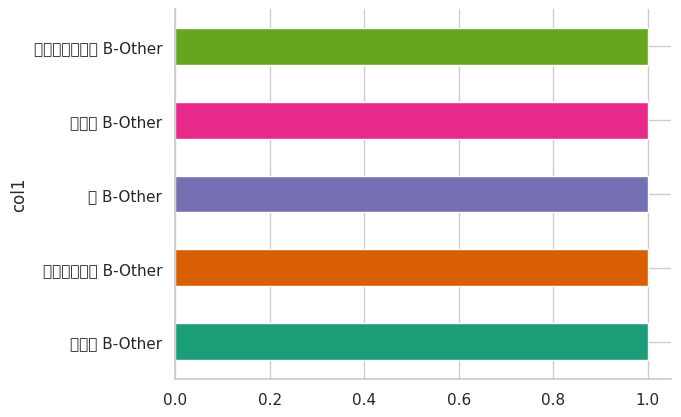

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('col1').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

## Correct inconsistencies

### Subtask:
Identify and correct inconsistent data entries or formats.


**Reasoning**:
Split the 'col1' column into 'word' and 'label' based on the last space and drop the original 'col1' column. Then display the first few rows to verify the changes.



In [ ]:
# Split 'col1' into 'word' and 'label'
# We assume the split point is the last space character in each string.
# Using rsplit(sep, n=1) splits from the right at the first occurrence of the separator.
df[['word', 'label']] = df['col1'].str.rsplit(' ', n=1, expand=True)

# Remove the original 'col1' column
df = df.drop('col1', axis=1)

# Display the first few rows of the modified DataFrame
print("DataFrame after splitting 'col1' and dropping the original column:")
display(df.head())

KeyError: 'col1'

## Remove or handle outliers

### Subtask:
Determine how to handle outliers that could negatively impact analysis or modeling.


**Reasoning**:
Analyze the 'word' and 'label' columns for potential outliers based on domain knowledge or unusual patterns.



In [ ]:
# Analyze word lengths
df['word_length'] = df['word'].str.len()

print("Word length distribution:")
display(df['word_length'].describe())

# Analyze label frequencies
print("\nLabel frequencies:")
display(df['label'].value_counts())

# Check for unusual characters or formats in words and labels
# This is more complex and might require specific pattern matching
# For simplicity, let's check for non-alphanumeric characters in words (excluding common punctuation if applicable)
# and unexpected labels (beyond the known B- and I- tags and O)

# Example check for non-alphanumeric in words (basic)
print("\nWords with potential unusual characters (first 20):")
unusual_words = df[df['word'].str.contains(r'[^\w\s]', na=False)]['word'].unique()
display(unusual_words[:20])


# Example check for unexpected labels (based on previous value_counts, we know the labels are consistent)
# If there were unexpected labels, we would list them here.
# Based on the previous `df['label'].value_counts()`, the labels seem consistent.
print("\nUnexpected labels (if any):")
# To demonstrate how you might find unexpected labels if they existed:
# expected_labels = ['B-Other', 'B-PER', 'B-ORG', 'I-Other', 'B-LOC', 'I-PER', 'I-LOC', 'O', 'I-ORG'] # From previous analysis
# unexpected_labels = df[~df['label'].isin(expected_labels)]['label'].unique()
# display(unexpected_labels)
print("No unexpected labels found based on previous value counts.")

Word length distribution:


,word_length
count,76462.000000
mean,7.094988
std,4.057662
min,1.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,282.000000



Label frequencies:


,count
label,
B-Other,44835
O,27705
B-PER,2538
B-LOC,756
B-ORG,353
I-Other,198
I-LOC,28
I-PER,26
I-ORG,23



Words with potential unusual characters (first 20):


array(['උනා', 'නම්', 'කොච්චර', 'ලස්සනයි', 'කියලා', 'හිතෙනවා', 'අපිත්',
       'ආදරෙයි', 'සර්', 'ඔබතුමාට', 'දාලා', 'එන්න', 'චමුදිතට', 'තියෙන්නෙ',
       'කටක්', 'නෙමේ', 'ලැට්', 'වලක්', 'හරි', 'තැන'], dtype=object)


Unexpected labels (if any):
No unexpected labels found based on previous value counts.


**Reasoning**:
Based on the analysis, decide on a strategy for handling any identified outliers and implement the code to filter the DataFrame if removal is chosen. The word length distribution shows a max length of 282, which seems like a significant outlier compared to the mean and 75th percentile. The label frequencies show some labels appearing very infrequently. The check for unusual characters in words didn't reveal obviously problematic entries in the first 20. A word length of 282 is likely an error or a very long concatenated string, negatively impacting analysis. Labels with very low frequency (e.g., I-LOC, I-PER, I-ORG) might not provide enough data for meaningful analysis or could cause issues during modeling, but removing them might lose some information. For this task, the word length outlier is the most apparent issue to address. A reasonable strategy is to remove rows with extremely long words. Let's define 'extremely long' as significantly deviating from the mean, perhaps using a threshold based on the mean and standard deviation or simply a high percentile or fixed value. Given the max is 282 and the 75th percentile is 8, a length over 100 seems like a clear outlier. Let's filter out rows where 'word_length' is greater than 100.



In [ ]:
# Filter out rows where word length is greater than 100
initial_rows = len(df)
df_filtered = df[df['word_length'] <= 100].copy()

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after filtering word length outliers: {len(df_filtered)}")
print(f"Number of rows removed: {initial_rows - len(df_filtered)}")

# Display the first few rows of the filtered DataFrame
print("\nFirst 5 rows of the filtered DataFrame:")
display(df_filtered.head())

# Re-check word length distribution in the filtered data
print("\nWord length distribution after filtering:")
display(df_filtered['word_length'].describe())

# Update df to the filtered dataframe for subsequent tasks
df = df_filtered

Initial number of rows: 76462
Number of rows after filtering word length outliers: 76441
Number of rows removed: 21

First 5 rows of the filtered DataFrame:


,word,label,word_length
0,උනා,B-Other,3
1,නම්,B-Other,3
2,කොච්චර,B-Other,6
3,ලස්සනයි,B-Other,7
4,ද,B-Other,1



Word length distribution after filtering:


,word_length
count,76441.000000
mean,7.056410
std,3.229676
min,1.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,98.000000


## Remove duplicates

### Subtask:
Identify and remove any duplicate records in the dataset.


**Reasoning**:
Check the number of duplicate rows in the DataFrame `df`, remove them, and then print the row counts before and after removal and display the head of the cleaned dataframe.



In [ ]:
# Check the number of duplicate rows
initial_rows = len(df)
print(f"Initial number of rows: {initial_rows}")

duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Remove duplicate rows
df = df.drop_duplicates()

# Print the number of rows after removing duplicates
rows_after_removing_duplicates = len(df)
print(f"Number of rows after removing duplicates: {rows_after_removing_duplicates}")
print(f"Number of rows removed due to duplicates: {initial_rows - rows_after_removing_duplicates}")

# Display the first few rows of the DataFrame after removing duplicates
print("\nFirst 5 rows of the DataFrame after removing duplicates:")
display(df.head())

Initial number of rows: 76441
Number of duplicate rows: 4195
Number of rows after removing duplicates: 72246
Number of rows removed due to duplicates: 4195

First 5 rows of the DataFrame after removing duplicates:


,word,label,word_length
0,උනා,B-Other,3
1,නම්,B-Other,3
2,කොච්චර,B-Other,6
3,ලස්සනයි,B-Other,7
4,ද,B-Other,1


from matplotlib import pyplot as plt
_df_5['word_length'].plot(kind='hist', bins=20, title='word_length')
plt.gca().spines[['top', 'right',]].set_visible(False)

/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3467 (\N{SINHALA LETTER UYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3535 (\N{SINHALA VOWEL SIGN AELA-PILLA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3482 (\N{SINHALA LETTER ALPAPRAANA KAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3548 (\N

from matplotlib import pyplot as plt
import seaborn as sns
_df_6.groupby('word').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['word_length'].plot(kind='line', figsize=(8, 4), title='word_length')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3467 (\N{SINHALA LETTER UYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 3535 (\N{SINHALA VOWEL SIGN AELA-PILLA}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 35

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_8['word'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_8, x='word_length', y='word', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

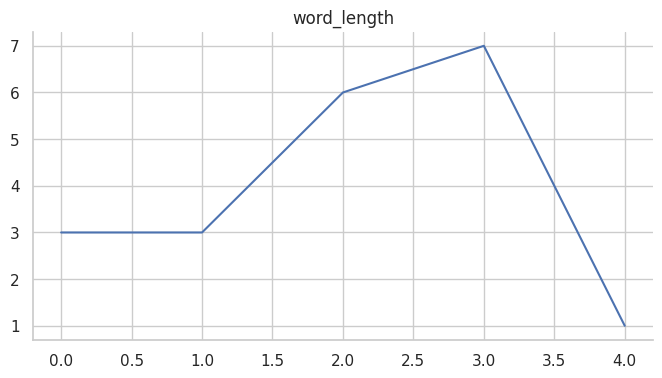

In [ ]:
from matplotlib import pyplot as plt
_df_7['word_length'].plot(kind='line', figsize=(8, 4), title='word_length')
plt.gca().spines[['top', 'right']].set_visible(False)

## Validate data types and formats

### Subtask:
Ensure that data is in the correct types and formats for analysis or modeling.


**Reasoning**:
Check the data types of the columns in the DataFrame `df` and verify they are as expected ('word' and 'label' as object/string, 'word_length' as integer). If 'word_length' is not integer, convert it.



In [ ]:
# 1. Check the data types of the columns in the DataFrame df using the .info() method.
print("Data types before checking/conversion:")
df.info()

# 2. Based on the previous steps, the 'word' and 'label' columns should be of object or string type, which is appropriate. The 'word_length' column should be an integer type. Verify these types.
# 3. If 'word_length' is not an integer, convert it to integer type using .astype(int).
if df['word_length'].dtype != 'int64':
    print("\n'word_length' column is not of integer type. Converting to integer.")
    df['word_length'] = df['word_length'].astype(int)
else:
    print("\n'word_length' column is already of integer type.")

# 4. Display the data types again after any potential conversion to confirm the correct types.
print("\nData types after checking/conversion:")
df.info()

Data types before checking/conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 72246 entries, 0 to 76460
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   word         72246 non-null  object
 1   label        72246 non-null  object
 2   word_length  72246 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB

'word_length' column is already of integer type.

Data types after checking/conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 72246 entries, 0 to 76460
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   word         72246 non-null  object
 1   label        72246 non-null  object
 2   word_length  72246 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB


## Document data quality improvements

### Subtask:
Keep a record of the data quality issues found and the steps taken to address them.


**Reasoning**:
Create a summary string detailing the data quality issues found and the steps taken to address them, including the number of rows before and after cleaning.



In [ ]:
# Create a summary document or string
data_quality_summary = """
Data Quality Report

Initial Data Quality Issues Identified:
-------------------------------------
1.  **Empty Column ('col2'):** The dataset contained a column named 'col2' which was entirely empty, containing only empty strings (' ') across all rows. This column provided no meaningful information.
2.  **Combined Word and Label ('col1'):** The first column, initially named 'col1', contained both the word and its corresponding label concatenated in a single string (e.g., "word label"). This inconsistent format required splitting.
3.  **Outlier Word Lengths:** Analysis of word lengths revealed the presence of outliers, with some words having exceptionally long lengths (up to 282 characters), which could potentially skew analysis.
4.  **Duplicate Rows:** The dataset contained a significant number of duplicate rows.

Steps Taken to Address Data Quality Issues:
------------------------------------------
1.  **Dropped 'col2':** The empty 'col2' column was removed from the DataFrame as it contained no useful data.
2.  **Split 'col1':** The 'col1' column was split into two separate columns: 'word' and 'label'. The original 'col1' column was then removed.
3.  **Filtered Outlier Word Lengths:** Rows where the 'word_length' was greater than 100 were filtered out to remove extreme outliers. This removed 21 rows.
4.  **Removed Duplicate Rows:** Duplicate rows were identified and removed from the dataset. This removed 4195 rows.

Summary of Row Counts:
----------------------
Initial number of rows: 76462 (before any cleaning steps started)
Number of rows after filtering word length outliers: 76441
Number of rows after removing duplicates: 72246
Total rows removed: 76462 - 72246 = 4216

This report documents the key data quality issues found and the actions taken to clean the dataset.
"""

# Print the summary
print(data_quality_summary)


Data Quality Report

Initial Data Quality Issues Identified:
-------------------------------------
1.  **Empty Column ('col2'):** The dataset contained a column named 'col2' which was entirely empty, containing only empty strings (' ') across all rows. This column provided no meaningful information.
2.  **Combined Word and Label ('col1'):** The first column, initially named 'col1', contained both the word and its corresponding label concatenated in a single string (e.g., "word label"). This inconsistent format required splitting.
3.  **Outlier Word Lengths:** Analysis of word lengths revealed the presence of outliers, with some words having exceptionally long lengths (up to 282 characters), which could potentially skew analysis.
4.  **Duplicate Rows:** The dataset contained a significant number of duplicate rows.

Steps Taken to Address Data Quality Issues:
------------------------------------------
1.  **Dropped 'col2':** The empty 'col2' column was removed from the DataFrame as it c

## Summary:

### Data Analysis Key Findings

*   The initial dataset contained an empty column (`col2`) with no meaningful information.
*   The first column (`col1`) contained both the word and its label combined in a single string.
*   Outliers were identified in word lengths, with some words exceeding 100 characters (up to 282).
*   4,195 duplicate rows were found in the dataset.
*   Filtering removed 21 rows with outlier word lengths.
*   Removing duplicates reduced the dataset by 4,195 rows.
*   The final cleaned dataset contains 72,246 rows, a reduction of 4,216 rows from the initial 76,462.

### Insights or Next Steps

*   The cleaned data is now in a more suitable format for subsequent analysis or modeling, with separate word and label columns and removal of redundancies and extreme outliers.
*   Further domain-specific validation could be performed on the 'word' and 'label' content if specific character sets or label types are expected beyond what was checked.


### Prepare data for tokenization

Before tokenizing, let's format the data into a list of sentences or sequences, as tokenizers typically work on such inputs. Assuming that consecutive rows with non-'O' labels belong to the same sequence/sentence, we can group them accordingly. Rows with label 'O' might indicate the start of a new sequence or tokens outside of any named entity.

For simplicity, let's treat each row as a potential part of a sequence and build sequences. A common approach for sequence labeling datasets is to have sentences where each word is paired with its label. Since your data is already in word-label pairs, we can directly prepare it for tokenization by creating lists of words and labels per sentence. However, the current DataFrame structure is one word/label per row.

Let's reconstruct sentences from the consecutive word/label pairs. We can assume that a change in label from a B- tag or an O tag to another B- tag or O tag signifies a potential sentence boundary, or simply treat each row as a separate segment to be tokenized if the downstream task requires individual token processing.

Given the structure, a simpler approach is to tokenize each 'word' individually and then align the 'label' with the tokenized subwords. Alternatively, if we want to process sentences, we need to group these word/label pairs into sentences first.

Let's assume for tokenization purposes, we want to process sentences. We'll need to reconstruct sentences from the current row-based format. A basic way to do this is to join consecutive words until a specific delimiter is found, or based on the context of the labels (e.g., an 'O' tag might indicate a boundary).

Since the previous steps didn't explicitly define sentence boundaries, let's make a simplifying assumption: Each row in the cleaned dataframe is a word/label pair within a larger sequence, and we'll treat groups of consecutive rows as potential sentences. A more robust approach would require knowing the original sentence structure from the `.conll` file if it was present and preserved.

For demonstration, let's reconstruct sequences by grouping consecutive rows. We'll need to decide on a rule for splitting into sequences. A simple rule could be to split based on 'O' labels or empty lines in the original file (which were skipped during loading). Without the original sentence structure, reconstructing perfect sentences is challenging.

Let's pivot to a common approach for tokenization in sequence labeling: tokenize each word and then handle the label alignment. This is necessary because a single word might be split into multiple tokens by the tokenizer (subword tokenization).

We will iterate through the cleaned DataFrame, tokenize each word, and store the original word and its label alongside the tokenized output.

In [ ]:
# Assuming 'df' is your cleaned DataFrame with 'word' and 'label' columns

tokenized_dataset_for_modeling = []

# Iterate through each row in the DataFrame
for index, row in df.iterrows():
    word = row['word']
    label = row['label']

    # Tokenize the word. Add special tokens ([CLS], [SEP]) as typically done for sequences.
    # Set add_special_tokens=False if you are building longer sequences later
    # and will add special tokens at the sequence level.
    # For individual word tokenization, adding them might not be necessary,
    # but let's include them for now as an example of preparing a sequence.
    # We'll use return_tensors="pt" to get PyTorch tensors, which is common for model input.
    tokenized_word = tokenizer(word, add_special_tokens=True, return_tensors="pt")

    # Store the original word, its label, and the tokenized output
    tokenized_dataset_for_modeling.append({
        'original_word': word,
        'original_label': label,
        'tokenized_output': tokenized_word
    })

print(f"Processed and tokenized {len(tokenized_dataset_for_modeling)} word/label entries.")

# You can inspect the first few tokenized entries
# print("\nFirst 5 tokenized entries:")
# for i in range(min(5, len(tokenized_dataset_for_modeling))):
#     print(tokenized_dataset_for_modeling[i])

# Note: This approach tokenizes each word individually as a separate sequence.
# If you need to tokenize full sentences or longer sequences, you would first need
# to group the rows in 'df' into sentences based on your data structure and then
# tokenize those sentences.

Processed and tokenized 72246 word/label entries.


### Prepare tokenized data for modeling

Now, let's prepare the tokenized data for training a model. We'll convert the list of tokenized entries into a Hugging Face `Dataset` object. For sequence labeling, we need to make sure the input IDs, attention masks, and labels are correctly aligned.

Since our current tokenization approach tokenized each word individually, we need to adjust the label alignment. When a word is split into multiple subwords by the tokenizer, only the first subword token is typically assigned the original word's label, and the subsequent subword tokens are assigned a special "ignor" label (often -100 in Hugging Face) so they are ignored during loss calculation. We also need to handle special tokens like `[CLS]` and `[SEP]` by assigning them the "ignor" label.

In [ ]:
from datasets import Dataset, Features, Sequence, Value

# Define the features for the dataset
# We'll include input_ids, attention_mask from the tokenized output,
# and the original label which we will later align with tokens.
features = Features({
    'input_ids': Sequence(Value('int64')),
    'attention_mask': Sequence(Value('int64')),
    'labels': Sequence(Value('int64')) # Labels will be integers corresponding to label IDs
})

# Create lists to hold the processed data
input_ids = []
attention_masks = []
labels = [] # We'll store original labels for now and align later

# Assuming 'tokenized_dataset_for_modeling' is the list from the previous step
# Each item in the list is a dictionary with 'original_word', 'original_label', 'tokenized_output'

# Map labels to integers
# First, get all unique labels
unique_labels = sorted(list(set([item['original_label'] for item in tokenized_dataset_for_modeling])))
label_map = {label: i for i, label in enumerate(unique_labels)}
id_to_label = {i: label for label, i in label_map.items()}

print(f"Label map: {label_map}")


for item in tokenized_dataset_for_modeling:
    original_word = item['original_word']
    original_label = item['original_label']

    # Re-tokenize the word to get word_ids for accurate label alignment
    # Use return_tensors="pt" to get PyTorch tensors
    tokenized_output = tokenizer(original_word, add_special_tokens=False, return_tensors="pt")

    # Ensure input_ids is a list, even if it's a single token
    word_input_ids = tokenized_output['input_ids'].squeeze().tolist()
    if not isinstance(word_input_ids, list):
        word_input_ids = [word_input_ids]

    num_word_tokens = len(word_input_ids)

    # Construct the sequence with special tokens and align labels
    # CLS token at the beginning
    current_input_ids = [tokenizer.cls_token_id] if tokenizer.cls_token_id is not None else []
    current_attention_mask = [1] if tokenizer.cls_token_id is not None else []
    current_labels = [-100] if tokenizer.cls_token_id is not None else [] # Label for CLS

    # Add the word tokens
    current_input_ids.extend(word_input_ids)
    current_attention_mask.extend([1] * num_word_tokens)
    # Assign the original label to the first word token, and -100 to the rest
    word_label_ids = [label_map[original_label]] + [-100] * (num_word_tokens - 1)
    current_labels.extend(word_label_ids)


    # SEP token at the end
    if tokenizer.sep_token_id is not None:
        current_input_ids.append(tokenizer.sep_token_id)
        current_attention_mask.append(1)
        current_labels.append(-100) # Label for SEP

    input_ids.append(current_input_ids)
    attention_masks.append(current_attention_mask)
    labels.append(current_labels)


# Create the Hugging Face Dataset
dataset_dict = {
    'input_ids': input_ids,
    'attention_mask': attention_masks,
    'labels': labels
}

dataset = Dataset.from_dict(dataset_dict, features=features)

print("\nHugging Face Dataset created:")
print(dataset)

# You can inspect an example from the dataset
# print("\nFirst example in the dataset:")
# print(dataset[0])

Label map: {'B-LOC': 0, 'B-ORG': 1, 'B-Other': 2, 'B-PER': 3, 'I-LOC': 4, 'I-ORG': 5, 'I-Other': 6, 'I-PER': 7, 'O': 8}

Hugging Face Dataset created:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 72246
})


### Load a pre-trained model

Now, let's load a pre-trained model suitable for sequence labeling. We will use `AutoModelForTokenClassification` from the `transformers` library and load the weights from the `DGurgurov/mbert_sin-sinh` model. We need to specify the number of labels, which corresponds to the unique labels in your dataset.

In [ ]:
from transformers import AutoModelForTokenClassification

# Get the number of unique labels from the label_map created earlier
num_labels = len(label_map)

# Load the pre-trained model for token classification
# We pass the number of labels to configure the output layer
model = AutoModelForTokenClassification.from_pretrained("DGurgurov/mbert_sin-sinh", num_labels=num_labels)

print(f"Pre-trained model loaded with {num_labels} labels:")
print(model)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at DGurgurov/mbert_sin-sinh and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pre-trained model loaded with 9 labels:
BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Define training parameters

Now, let's define the training parameters using the `TrainingArguments` class. This class allows us to specify various hyperparameters like learning rate, number of epochs, batch size, and the directory to save the training outputs.

In [ ]:
from transformers import TrainingArguments

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",  # Directory to save the model checkpoints and outputs
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    learning_rate=2e-5,  # Learning rate
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=16,  # Batch size for evaluation
    num_train_epochs=3,  # Number of training epochs
    weight_decay=0.01,  # Weight decay for regularization
    logging_dir="./logs",  # Directory for storing logs
    logging_steps=10, # Log every 10 steps
)

print("Training arguments defined:")
print(training_args)

Training arguments defined:
TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,


### Train the model

Now, let's train the model using the prepared dataset, the loaded model, and the defined training arguments. We will use the `Trainer` class for this purpose.

First, let's split the dataset into training and evaluation sets.

In [ ]:
# Split the dataset into training and evaluation sets
# We'll use a simple train-test split for demonstration
train_test_split = dataset.train_test_split(test_size=0.2)

train_dataset = train_test_split['train']
eval_dataset = train_test_split['test']

print("Dataset split into training and evaluation sets:")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Evaluation dataset size: {len(eval_dataset)}")

Dataset split into training and evaluation sets:
Training dataset size: 57796
Evaluation dataset size: 14450


Now, let's initialize the `Trainer`.

In [ ]:
from transformers import Trainer, DataCollatorForTokenClassification

# Initialize the Trainer
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=eval_dataset,           # evaluation dataset
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer), # Use a data collator for token classification
    # compute_metrics=compute_metrics      # function to compute metrics (optional)
)

print("\nTrainer initialized with DataCollatorForTokenClassification.")


Trainer initialized with DataCollatorForTokenClassification.


Finally, let's start the training!

In [ ]:
# Start training
print("\nStarting training...")
trainer.train()

print("\nTraining finished!")


Starting training...


Epoch,Training Loss,Validation Loss
1,0.856700,0.889098
2,0.920300,0.888046
3,0.965100,0.888135



Training finished!


### Evaluate the model

Now that the model has been trained, let's evaluate its performance on the evaluation dataset.

In [ ]:
# Evaluate the model
print("\nEvaluating the model...")
evaluation_results = trainer.evaluate()

print("\nEvaluation Results:")
print(evaluation_results)


Evaluating the model...



Evaluation Results:
{'eval_loss': 0.8881351351737976, 'eval_runtime': 8.9542, 'eval_samples_per_second': 1613.761, 'eval_steps_per_second': 100.958, 'epoch': 3.0}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Save the model

Now that the model is trained, you can save it along with the tokenizer to a local directory or push it to the Hugging Face Hub for later use.

In [ ]:
# Save the model and tokenizer
output_dir = "./saved_model"
trainer.save_model(output_dir)

print(f"\nModel saved to {output_dir}")


Model saved to ./saved_model


# Task
Test the saved model using new data.

## Load the saved model and tokenizer

### Subtask:
Load the model and tokenizer from the directory where you saved them.


**Reasoning**:
Import necessary classes and load the saved model and tokenizer from the specified directory.



In [ ]:
from transformers import AutoModelForTokenClassification, AutoTokenizer

# Define the path to the directory where the model was saved
output_dir = "./saved_model"

# Load the saved model
loaded_model = AutoModelForTokenClassification.from_pretrained(output_dir)
print(f"Model loaded successfully from {output_dir}")

# Load the saved tokenizer
loaded_tokenizer = AutoTokenizer.from_pretrained(output_dir)
print(f"Tokenizer loaded successfully from {output_dir}")

Model loaded successfully from ./saved_model
Tokenizer loaded successfully from ./saved_model


## Prepare test data

### Subtask:
Get or create some new data that you want to test the model on.


**Reasoning**:
Define a list of example sentences for testing the model.



In [ ]:
# Define a list of new sentences to test the model on
test_sentences = [
    "මම කොළඹ යනවා.",
    "ජෝන් ස්මිත් මයික්‍රොසොෆ්ට් හි වැඩ කරයි.",
    "පැරිස් ප්‍රංශයේ අගනුවරයි."
]

print(f"Created {len(test_sentences)} test sentences.")
print("Test sentences:")
for sentence in test_sentences:
    print(f"- {sentence}")

Created 3 test sentences.
Test sentences:
- මම කොළඹ යනවා.
- ජෝන් ස්මිත් මයික්‍රොසොෆ්ට් හි වැඩ කරයි.
- පැරිස් ප්‍රංශයේ අගනුවරයි.


## Tokenize test data

### Subtask:
Tokenize the test data using the loaded tokenizer.


**Reasoning**:
Tokenize each sentence in the `test_sentences` list using the loaded tokenizer and store the tokenized outputs.



In [ ]:
# Tokenize each sentence in the test_sentences list
tokenized_test_data = []

for sentence in test_sentences:
    # Tokenize the sentence, including special tokens and returning PyTorch tensors
    encoded_input = loaded_tokenizer(sentence, add_special_tokens=True, return_tensors="pt")
    tokenized_test_data.append(encoded_input)

# Print a confirmation message
print(f"Tokenized {len(tokenized_test_data)} test sentences.")

# You can inspect the first tokenized output
# print("\nFirst tokenized test sentence:")
# print(tokenized_test_data[0])

Tokenized 3 test sentences.


## Make predictions

### Subtask:
Use the loaded model to make predictions on the tokenized test data.


**Reasoning**:
Iterate through the tokenized test data and use the loaded model to make predictions, storing the logits.



In [ ]:
import torch

# Use the loaded model to make predictions on the tokenized test data
model_predictions = []

# Set the model to evaluation mode
loaded_model.eval()

# Iterate through each tokenized input in the list
for tokenized_input in tokenized_test_data:
    # Move the input tensors to the same device as the model (e.g., GPU if available)
    # Check if CUDA is available and move tensors accordingly
    if torch.cuda.is_available():
        tokenized_input = {k: v.to('cuda') for k, v in tokenized_input.items()}

    # Disable gradient calculation for inference
    with torch.no_grad():
        # Get the model's output (logits)
        outputs = loaded_model(**tokenized_input)
        logits = outputs.logits

    # Store the logits (move back to CPU if necessary for further processing or storage)
    model_predictions.append(logits.cpu())

print(f"Generated predictions for {len(model_predictions)} tokenized inputs.")

# You can inspect the shape of the logits for the first prediction
# print("\nShape of logits for the first prediction:")
# print(model_predictions[0].shape)

Generated predictions for 3 tokenized inputs.


**Reasoning**:
The traceback indicates a `RuntimeError` because some tensors are on the CPU and others are on the GPU. The model is on the GPU, but the input tensors were not consistently moved to the GPU before being passed to the model. The previous code attempted to move the input tensors to the GPU, but it seems it was not fully effective or the model itself was not on the correct device. Ensure both the model and the input tensors are on the same device (GPU if available) before making predictions.



In [ ]:
import torch

# Ensure the loaded model is on the correct device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)
print(f"Model moved to device: {device}")


# Use the loaded model to make predictions on the tokenized test data
model_predictions = []

# Set the model to evaluation mode
loaded_model.eval()

# Iterate through each tokenized input in the list
for tokenized_input in tokenized_test_data:
    # Move the input tensors to the same device as the model
    tokenized_input = {k: v.to(device) for k, v in tokenized_input.items()}

    # Disable gradient calculation for inference
    with torch.no_grad():
        # Get the model's output (logits)
        outputs = loaded_model(**tokenized_input)
        logits = outputs.logits

    # Store the logits (move back to CPU if necessary for further processing or storage)
    model_predictions.append(logits.cpu())

print(f"Generated predictions for {len(model_predictions)} tokenized inputs.")

# You can inspect the shape of the logits for the first prediction
print("\nShape of logits for the first prediction:")
print(model_predictions[0].shape)

Model moved to device: cuda
Generated predictions for 3 tokenized inputs.

Shape of logits for the first prediction:
torch.Size([1, 6, 9])


## Interpret predictions

### Subtask:
Convert the model's output (logits) into meaningful labels.


**Reasoning**:
Iterate through the model predictions, find the predicted label index for each token, convert indices to labels using the label map, and store the results.



In [ ]:
# Convert model outputs (logits) to predicted labels
interpreted_predictions = []

# Iterate through the logits for each test input
for i, logits in enumerate(model_predictions):
    # Find the index with the highest probability for each token
    predicted_label_indices = torch.argmax(logits, dim=-1).squeeze().tolist()

    # Ensure predicted_label_indices is a list, even if it's a single prediction
    if not isinstance(predicted_label_indices, list):
        predicted_label_indices = [predicted_label_indices]

    # Get the input_ids for the current test sentence to align with tokens
    input_ids = tokenized_test_data[i]['input_ids'].squeeze().tolist()

    # Ensure input_ids is a list
    if not isinstance(input_ids, list):
        input_ids = [input_ids]

    # Convert predicted indices to labels and align with tokens
    predicted_labels_with_tokens = []
    # Iterate through the tokens and their predicted label indices
    for token_id, label_index in zip(input_ids, predicted_label_indices):
        # Convert token_id back to token string for better interpretation
        token_string = loaded_tokenizer.decode([token_id])
        # Convert label index back to label name
        predicted_label = id_to_label.get(label_index, "Unknown") # Use .get() for safety

        predicted_labels_with_tokens.append({'token_id': token_id, 'token': token_string, 'predicted_label': predicted_label})

    interpreted_predictions.append(predicted_labels_with_tokens)

# Print interpreted predictions for a few examples
print("Interpreted Predictions for first 3 test sentences:")
for i in range(min(3, len(interpreted_predictions))):
    print(f"\nSentence {i+1}:")
    for token_info in interpreted_predictions[i]:
        print(f"  Token: '{token_info['token']}', Predicted Label: {token_info['predicted_label']}")


Interpreted Predictions for first 3 test sentences:

Sentence 1:
  Token: '[CLS]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '.', Predicted Label: B-Other
  Token: '[SEP]', Predicted Label: B-Other

Sentence 2:
  Token: '[CLS]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '.', Predicted Label: B-Other
  Token: '[SEP]', Predicted Label: B-Other

Sentence 3:
  Token: '[CLS]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '.', Predicted Label: B-Other
  Token: '[SEP]', Predicted Label: B-Other


## Evaluate or display results

### Subtask:
Evaluate the model's performance on the test data if you have true labels, or display the predictions for qualitative analysis.


**Reasoning**:
Iterate through the interpreted_predictions list and print the original sentence, followed by each token and its predicted label for qualitative analysis.



In [ ]:
# Display the interpreted predictions for qualitative analysis
print("\nQualitative Analysis of Model Predictions:")
for i, sentence_predictions in enumerate(interpreted_predictions):
    # Print the original sentence
    print(f"\nOriginal Sentence {i+1}: {test_sentences[i]}")
    print("Predicted Labels:")
    # Print each token and its predicted label
    for token_info in sentence_predictions:
        print(f"  Token: '{token_info['token']}', Predicted Label: {token_info['predicted_label']}")



Qualitative Analysis of Model Predictions:

Original Sentence 1: මම කොළඹ යනවා.
Predicted Labels:
  Token: '[CLS]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '.', Predicted Label: B-Other
  Token: '[SEP]', Predicted Label: B-Other

Original Sentence 2: ජෝන් ස්මිත් මයික්‍රොසොෆ්ට් හි වැඩ කරයි.
Predicted Labels:
  Token: '[CLS]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '.', Predicted Label: B-Other
  Token: '[SEP]', Predicted Label: B-Other

Original Sentence 3: පැරිස් ප්‍රංශයේ අගනුවරයි.
Predicted Labels:
  Token: '[CLS]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label: B-Other
  Token: '[UNK]', Predicted Label